**Task:3**


**Text Preprocessing, Tokenization, and Sequence Padding:**

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


**Text Preprocessing, Tokenization, and Sequence Padding:**

In this section, i prepare the raw tweet data for the deep learning models.
The process includes:
1. **Data Cleaning**: Lowercasing, removing noise (URLs, @mentions, hashtags, numbers), and expanding contractions.
2. **Linguistic Processing**: Removing stopwords and applying lemmatization to reduce words to their base form.
3. **Exploratory Data Analysis (EDA)**: Visualizing the cleaned data using a Word Cloud.
4. **Vectorization**: Converting text into numerical sequences using the Keras Tokenizer.
5. **Sequence Normalization**: Applying percentile-based padding to ensure uniform input length for the RNN and LSTM models.

In [4]:
import pandas as pd
import numpy as np
import re
import nltk
import matplotlib.pyplot as plt
import seaborn as sns
import time
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from wordcloud import WordCloud
!pip install gensim
!pip install contractions
import contractions

import gensim.downloader as api
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, SimpleRNN, LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.metrics import classification_report

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 73.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 345.1/345.1 kB 25.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 114.9/114.9 kB 14.2 MB/s eta 0:00:00


In [5]:

nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...


True

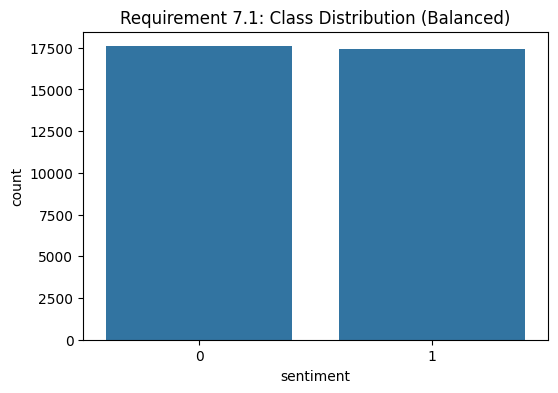

Total Training Rows: 35000


In [6]:
import seaborn as sns
# Load files
train_df = pd.read_csv('train_movie_review.csv').dropna(subset=['review', 'sentiment'])
val_df = pd.read_csv('val_movie_review.csv').dropna(subset=['review', 'sentiment'])
test_df = pd.read_csv('test_movie_review.csv').dropna(subset=['review', 'sentiment'])

# Visualize Class Distribution
plt.figure(figsize=(6,4))
sns.countplot(x='sentiment', data=train_df)
plt.title('Requirement 7.1: Class Distribution (Balanced)')
plt.show()
print(f"Total Training Rows: {len(train_df)}")

In [7]:
def clean_text(text):
    text = str(text).lower()
    text = contractions.fix(text)

    text = re.sub(r'http\S+|www\S+|https\S+', '', text)
    text = re.sub(r'\@\w+|\#','', text)
    text = re.sub(r'[^a-z\s]', '', text)

    stop_words = set(stopwords.words('english'))
    excluded_words = {"not", "no", "never", "none", "neither", "nor"}
    stop_words = stop_words - excluded_words

    lemmatizer = WordNetLemmatizer()
    words = text.split()
    cleaned = [lemmatizer.lemmatize(w) for w in words if w not in stop_words]
    return " ".join(cleaned)

train_df['cleaned'] = train_df['review'].apply(clean_text)
val_df['cleaned'] = val_df['review'].apply(clean_text)
test_df['cleaned'] = test_df['review'].apply(clean_text)
print("Cleaning Complete.")

Cleaning Complete.


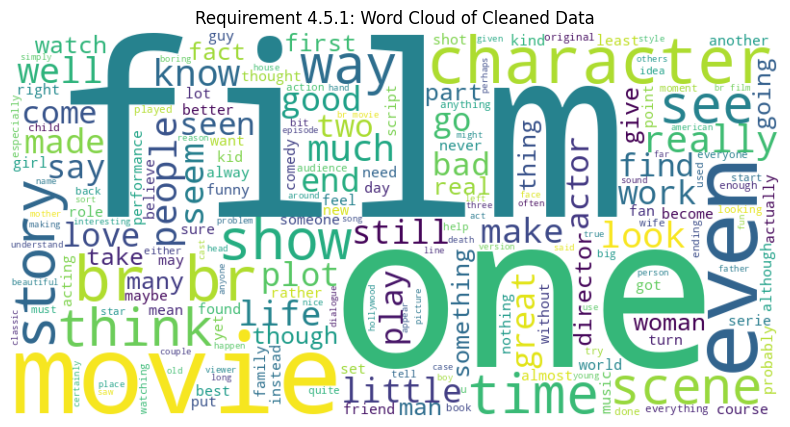

In [8]:
wordcloud = WordCloud(width=800, height=400, background_color='white').generate(" ".join(train_df['cleaned']))
plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title("Requirement 4.5.1: Word Cloud of Cleaned Data")
plt.show()

In [9]:
MAX_WORDS = 10000
tokenizer = Tokenizer(num_words=MAX_WORDS, oov_token="<OOV>")
tokenizer.fit_on_texts(train_df['cleaned'])

# 95th Percentile calculation
lengths = [len(s.split()) for s in train_df['cleaned']]
max_len = int(np.percentile(lengths, 95))
print(f"Chosen Padding Length: {max_len}")

X_train = pad_sequences(tokenizer.texts_to_sequences(train_df['cleaned']), maxlen=max_len, padding='post')
X_val = pad_sequences(tokenizer.texts_to_sequences(val_df['cleaned']), maxlen=max_len, padding='post')
X_test = pad_sequences(tokenizer.texts_to_sequences(test_df['cleaned']), maxlen=max_len, padding='post')

y_train = train_df['sentiment'].astype(int).values
y_val = val_df['sentiment'].astype(int).values
y_test = test_df['sentiment'].astype(int).values

Chosen Padding Length: 315


 **Model Building and Training:**
In this section, i develop three distinct architectures to compare performance:
1. **Model 1**: Simple RNN with a trainable Embedding layer.
2. **Model 2**: LSTM with a trainable Embedding layer.
3. **Model 3**: LSTM leveraging Pre-trained GloVe (Word2Vec) embeddings.

Each model is compiled using the **Adam optimizer** and **Binary Cross-entropy loss**. i implement **Early Stopping** to prevent overfitting by monitoring validation loss.

In [10]:
vocab_size = MAX_WORDS
# --- Model 1: Simple RNN ---
model1 = Sequential()
model1.add(Embedding(input_dim=vocab_size,
          output_dim=128,
          input_length=max_len))

model1.add(SimpleRNN(128,dropout=0.2,
                     recurrent_dropout=0.2))

model1.add(Dense(1, activation='sigmoid'))

model1.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


In [11]:
# --- Model 2: LSTM (Trainable) ---
model2 = Sequential()

model2.add(Embedding(
            input_dim=vocab_size,
            output_dim=128,
            input_length=max_len))


model2.add(LSTM(128, dropout=0.2, recurrent_dropout=0.2))

model2.add(Dense(32, activation='relu'))

model2.add(Dense(1, activation='sigmoid'))

model2.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

In [12]:
import gensim.downloader as api
import numpy as np

# Load pretrained Twitter GloVe embeddings
print("Loading GloVe Twitter-50 embeddings...")

embedding_model = api.load('glove-twitter-50')

print("Embeddings loaded successfully.")
embedding_dim = 50
embedding_matrix = np.zeros((vocab_size, embedding_dim))
for word, i in tokenizer.word_index.items():

    if i >= vocab_size:
        continue

    if word in embedding_model:
        embedding_matrix[i] = embedding_model[word]

print("Embedding matrix shape:", embedding_matrix.shape)

# -------------------------------
# Model 3: LSTM + Pretrained Word2Vec
# -------------------------------

model3 = Sequential()

# Pretrained Embedding Layer
model3.add(
    Embedding(
        input_dim=vocab_size,
        output_dim=embedding_dim,
        weights=[embedding_matrix],
        input_length=max_len,
        trainable=True
    )
)

# LSTM Layer
model3.add(
    LSTM(
        128,
        dropout=0.2,
        recurrent_dropout=0.2
    )
)

# Output Layer
model3.add(
    Dense(1, activation='sigmoid')
)

# Compile Model
model3.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model3.build(input_shape=(None, max_len))
# Model Summary
model3.summary()

Loading GloVe Twitter-50 embeddings...
[==================================================] 100.0% 199.5/199.5MB downloaded
Embeddings loaded successfully.
Embedding matrix shape: (10000, 50)


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_2 (Embedding)         │ (None, 315, 50)        │       500,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 128)            │        91,648 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 591,777 (2.26 MB)

 Trainable params: 591,777 (2.26 MB)

 Non-trainable params: 0 (0.00 B)

In [13]:
early_stop = EarlyStopping(monitor='val_loss', patience=2, restore_best_weights=True)

def train_and_time(model, name):
  print(f"\nTraining {name}...")
  start = time.time()
  history = model.fit(X_train, y_train, epochs=15,
                      validation_data=(X_val, y_val),
                      callbacks=[early_stop], batch_size=32)


  print(f"{name} trained in {time.time() - start} seconds.")
  return history, (time.time() - start)


In [14]:
h1, t1 = train_and_time(model1, "RNN")


Training RNN...
Epoch 1/15
1094/1094 ━━━━━━━━━━━━━━━━━━━━ 38s 31ms/step - accuracy: 0.5015 - loss: 0.7058 - val_accuracy: 0.5062 - val_loss: 0.7020
Epoch 2/15
1094/1094 ━━━━━━━━━━━━━━━━━━━━ 28s 26ms/step - accuracy: 0.5007 - loss: 0.6999 - val_accuracy: 0.4990 - val_loss: 0.6974
Epoch 3/15
1094/1094 ━━━━━━━━━━━━━━━━━━━━ 30s 28ms/step - accuracy: 0.5031 - loss: 0.6985 - val_accuracy: 0.4970 - val_loss: 0.6947
Epoch 4/15
1094/1094 ━━━━━━━━━━━━━━━━━━━━ 29s 26ms/step - accuracy: 0.5013 - loss: 0.6969 - val_accuracy: 0.4954 - val_loss: 0.6996
Epoch 5/15
1094/1094 ━━━━━━━━━━━━━━━━━━━━ 28s 26ms/step - accuracy: 0.5039 - loss: 0.6960 - val_accuracy: 0.5020 - val_loss: 0.6932
Epoch 6/15
1094/1094 ━━━━━━━━━━━━━━━━━━━━ 28s 26ms/step - accuracy: 0.5034 - loss: 0.6957 - val_accuracy: 0.4986 - val_loss: 0.7018
Epoch 7/15
1094/1094 ━━━━━━━━━━━━━━━━━━━━ 28s 26ms/step - accuracy: 0.5039 - loss: 0.6953 - val_accuracy: 0.4984 - val_loss: 0.7040
RNN trained in 209.91722702980042 seconds.


In [15]:
h2, t2 = train_and_time(model2, "LSTM")


Training LSTM...
Epoch 1/15
1094/1094 ━━━━━━━━━━━━━━━━━━━━ 1231s 1s/step - accuracy: 0.5083 - loss: 0.6926 - val_accuracy: 0.5108 - val_loss: 0.6882
Epoch 2/15
1094/1094 ━━━━━━━━━━━━━━━━━━━━ 1219s 1s/step - accuracy: 0.5170 - loss: 0.6821 - val_accuracy: 0.5058 - val_loss: 0.6875
Epoch 3/15
1094/1094 ━━━━━━━━━━━━━━━━━━━━ 1217s 1s/step - accuracy: 0.7038 - loss: 0.5390 - val_accuracy: 0.8416 - val_loss: 0.3961
Epoch 4/15
1094/1094 ━━━━━━━━━━━━━━━━━━━━ 1221s 1s/step - accuracy: 0.8830 - loss: 0.3004 - val_accuracy: 0.8788 - val_loss: 0.3081
Epoch 5/15
1094/1094 ━━━━━━━━━━━━━━━━━━━━ 1223s 1s/step - accuracy: 0.9204 - loss: 0.2170 - val_accuracy: 0.8886 - val_loss: 0.2915
Epoch 6/15
1094/1094 ━━━━━━━━━━━━━━━━━━━━ 1214s 1s/step - accuracy: 0.9454 - loss: 0.1605 - val_accuracy: 0.8748 - val_loss: 0.3253
Epoch 7/15
1094/1094 ━━━━━━━━━━━━━━━━━━━━ 1213s 1s/step - accuracy: 0.9639 - loss: 0.1166 - val_accuracy: 0.8840 - val_loss: 0.3390
LSTM trained in 8537.53947353363 seconds.


In [16]:
h3, t3 = train_and_time(model3, "Word2Vec")


Training Word2Vec...
Epoch 1/15
1094/1094 ━━━━━━━━━━━━━━━━━━━━ 1234s 1s/step - accuracy: 0.5101 - loss: 0.6919 - val_accuracy: 0.5026 - val_loss: 0.6890
Epoch 2/15
1094/1094 ━━━━━━━━━━━━━━━━━━━━ 1206s 1s/step - accuracy: 0.5188 - loss: 0.6872 - val_accuracy: 0.7296 - val_loss: 0.6373
Word2Vec trained in 2439.5566222667694 seconds.


313/313 ━━━━━━━━━━━━━━━━━━━━ 71s 225ms/step


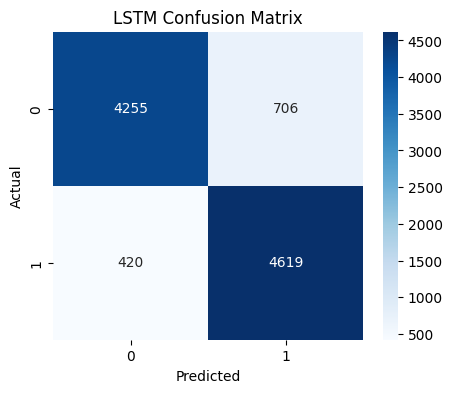

In [17]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

preds = (model2.predict(X_test) > 0.5).astype(int)

cm = confusion_matrix(y_test, preds)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

plt.title('LSTM Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')

plt.show()

In [18]:
def get_metrics(model, name, training_time):
    preds = (model.predict(X_test) > 0.5).astype(int)
    return {
        "Model": name,
        "Accuracy": accuracy_score(y_test, preds),
        "Precision": precision_score(y_test, preds),
        "Recall": recall_score(y_test, preds),
        "F1": f1_score(y_test, preds),
        "Time (s)": training_time
    }

results = pd.DataFrame([get_metrics(model1, "RNN", t1),
                        get_metrics(model2, "LSTM", t2),
                        get_metrics(model3, "Word2Vec-LSTM", t3)])
print(results)

print("\nRNN Classification Report")
print(classification_report(y_test,
      (model1.predict(X_test) > 0.5).astype(int)))

print("\nLSTM Classification Report")
print(classification_report(y_test,
      (model2.predict(X_test) > 0.5).astype(int)))

print("\nWord2Vec-LSTM Classification Report")
print(classification_report(y_test,
      (model3.predict(X_test) > 0.5).astype(int)))




313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step
313/313 ━━━━━━━━━━━━━━━━━━━━ 69s 222ms/step
313/313 ━━━━━━━━━━━━━━━━━━━━ 71s 225ms/step
           Model  Accuracy  Precision    Recall        F1     Time (s)
0            RNN    0.4932   0.497922  0.689621  0.578299   209.917310
1           LSTM    0.8874   0.867418  0.916650  0.891355  8537.539553
2  Word2Vec-LSTM    0.5083   0.722628  0.039294  0.074534  2439.556703

RNN Classification Report
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step
              precision    recall  f1-score   support

           0       0.48      0.29      0.37      4961
           1       0.50      0.69      0.58      5039

    accuracy                           0.49     10000
   macro avg       0.49      0.49      0.47     10000
weighted avg       0.49      0.49      0.47     10000


LSTM Classification Report
313/313 ━━━━━━━━━━━━━━━━━━━━ 70s 225ms/step
              precision    recall  f1-score   support

           0       0.91      0.86      0.88      4961
           

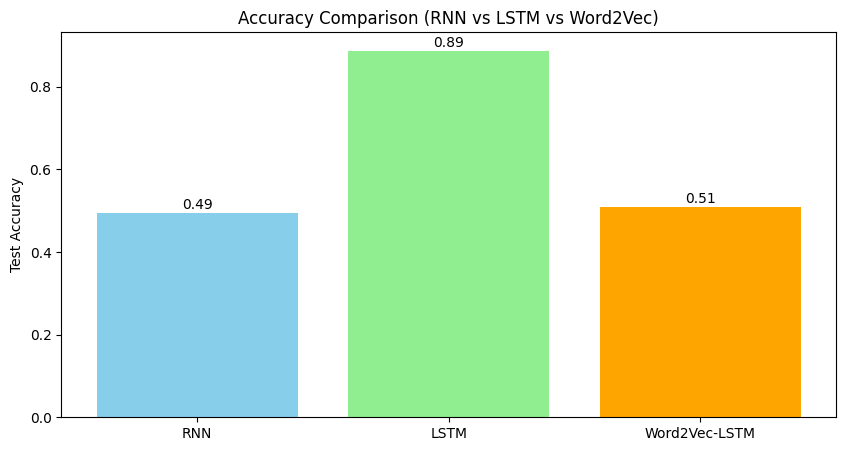

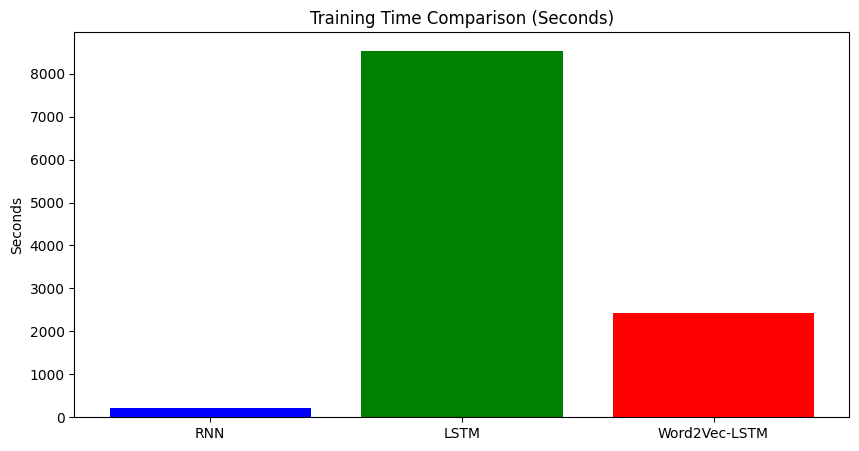

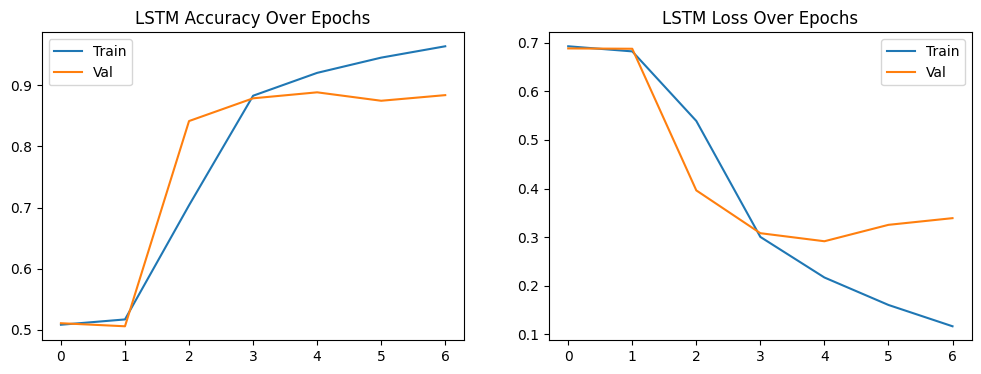

In [41]:
import matplotlib.pyplot as plt

# Compare Accuracy of all 3 models
model_names = results['Model'].tolist()
accuracies = results['Accuracy'].tolist()

plt.figure(figsize=(10, 5))
plt.bar(model_names, accuracies, color=['skyblue', 'lightgreen', 'orange'])
plt.title('Accuracy Comparison (RNN vs LSTM vs Word2Vec)')
plt.ylabel('Test Accuracy')
for i, v in enumerate(accuracies):
    plt.text(i, v + 0.01, f"{v:.2f}", ha='center')
plt.show()

# Compare Training Time (Computational Efficiency)
times = results['Time (s)'].tolist()
plt.figure(figsize=(10, 5))
plt.bar(model_names, times, color=['blue', 'green', 'red'])
plt.title('Training Time Comparison (Seconds)')
plt.ylabel('Seconds')
plt.show()

# Plot Training Curves for the Best Model (LSTM)
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(h2.history['accuracy'], label='Train')
plt.plot(h2.history['val_accuracy'], label='Val')
plt.title('LSTM Accuracy Over Epochs')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(h2.history['loss'], label='Train')
plt.plot(h2.history['val_loss'], label='Val')
plt.title('LSTM Loss Over Epochs')
plt.legend()
plt.show()

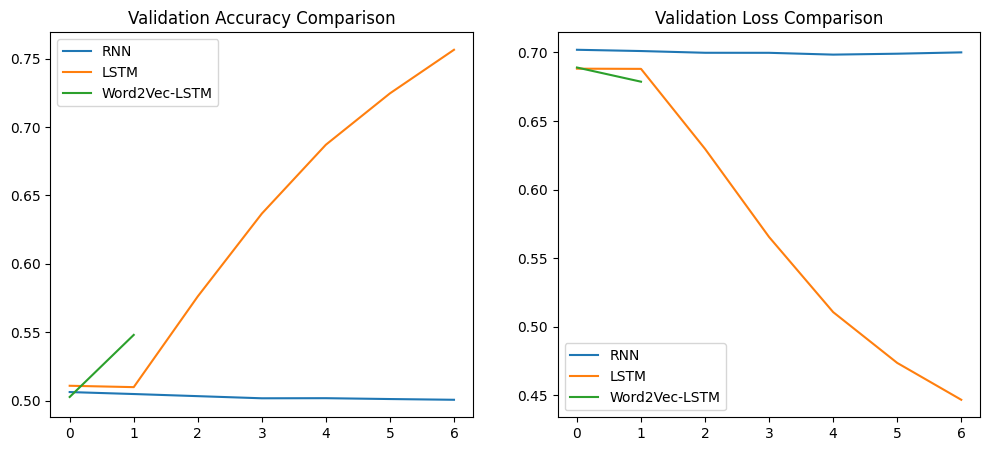

In [42]:


#  Accuracy & Loss Comparison
def smooth_curve(points, factor=0.8):
    smoothed_points = []
    for point in points:
        if smoothed_points:
            previous = smoothed_points[-1]
            smoothed_points.append(previous * factor + point * (1 - factor))
        else:
            smoothed_points.append(point)
    return smoothed_points

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(smooth_curve(h1.history['val_accuracy']), label='RNN')
plt.plot(smooth_curve(h2.history['val_accuracy']), label='LSTM')
plt.plot(smooth_curve(h3.history['val_accuracy']), label='Word2Vec-LSTM')
plt.title('Validation Accuracy Comparison')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(smooth_curve(h1.history['val_loss']), label='RNN')
plt.plot(smooth_curve(h2.history['val_loss']), label='LSTM')
plt.plot(smooth_curve(h3.history['val_loss']), label='Word2Vec-LSTM')
plt.title('Validation Loss Comparison')
plt.legend()
plt.show()


**Error Analysis:**
To understand model limitations, i examine cases where the best-performing model (LSTM) failed.
i analyze the trade-off between **Model Complexity** (LSTM gates) and **Performance**, and suggest improvements like using Attention mechanisms or larger datasets.

In [23]:
# Analyzing Model 2 (Best Model)
preds = (model2.predict(X_test) > 0.5).astype(int)
errors = np.where(preds.flatten() != y_test)[0]

print("\n--- Requirement 4.5.4: Error Analysis ---")
for i in errors[:3]:
    print(f"Review Text: {test_df['review'].iloc[i][:200]}...")
    print(f"Actual: {y_test[i]}, Predicted: {preds[i][0]}")
    print("Reason: Likely due to sarcasm or complex negations.")
    print("-" * 30)

313/313 ━━━━━━━━━━━━━━━━━━━━ 71s 227ms/step

--- Requirement 4.5.4: Error Analysis ---
Review Text: I really liked this Summerslam due to the look of the arena, the curtains and just the look overall was interesting to me for some reason. Anyways, this could have been one of the best Summerslam's ev...
Actual: 1, Predicted: 0
Reason: Likely due to sarcasm or complex negations.
------------------------------
Review Text: Okay, I didn't get the Purgatory thing the first time I watched this episode. It seemed like something significant was going on that I couldn't put my finger on. This time those Costa Mesa fires on TV...
Actual: 1, Predicted: 0
Reason: Likely due to sarcasm or complex negations.
------------------------------
Review Text: The production quality, cast, premise, authentic New England (Waterbury, CT?) locale and lush John Williams score should have resulted in a 3-4 star collectors item. Unfortunately, all we got was a pa...
Actual: 1, Predicted: 0
Reason: Likely due to sa

**GUI for Real-Time Prediction:**
Using the **Gradio** library, i provide an interactive interface. This allows users to input any custom movie review and receive an immediate sentiment prediction from our trained LSTM model.

In [32]:
import gradio as gr

def predict_movie(text):
    c = clean_text(text)
    seq = pad_sequences(tokenizer.texts_to_sequences([c]), maxlen=max_len, padding='post')
    p = model2.predict(seq)[0][0] # Using Model 2 as it is the most accurate
    return f"Positive Sentiment ({p:.2f})" if p > 0.5 else f"Negative Sentiment ({p:.2f})"

gr.Interface(fn=predict_movie, inputs="text", outputs="text", title="Final Project: Movie Review AI").launch(share=True)

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://e4088dddde200f0389.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
